# 04 — Evaluation

**Input:** out-of-fold predictions from `data/processed/oof_predictions.parquet` (produced by `03_modeling.ipynb`)
**Output:** evaluation figures saved to `reports/figures/` for README embedding, plus a quantitative threshold analysis table.

## What this notebook does

This is the evaluation section a credit team would actually care about. We move beyond the headline CV numbers from the modelling notebook and look at:

1. **ROC and PR curves** comparing all three models on the same axes
2. **KS statistic** — the credit-scoring-specific separation measure
3. **Calibration plot** — does the model's stated 30% risk correspond to a 30% observed default rate?
4. **Threshold analysis** — at what threshold should the model be deployed, and what does the business trade-off look like?
5. **Business framing** — careful, honest interpretation of what the model can and cannot tell us


## 1. Setup and load OOF predictions

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from src.evaluation import (
    compute_headline_metrics,
    plot_roc_pr_curves,
    plot_calibration,
    threshold_analysis,
    ks_statistic,
)

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"
sns.set_style("whitegrid")

print("Setup complete.")

Setup complete.


In [2]:
oof = pd.read_parquet(PROCESSED_DIR / "oof_predictions.parquet")
print(f"OOF predictions shape: {oof.shape}")
print(f"\nColumns: {oof.columns.tolist()}")
oof.head()

OOF predictions shape: (307507, 5)

Columns: ['SK_ID_CURR', 'TARGET', 'lr_pred', 'lgb_base_pred', 'lgb_tuned_pred']


,SK_ID_CURR,TARGET,lr_pred,lgb_base_pred,lgb_tuned_pred
0,100002,1,0.942005,0.886320,0.883817
1,100003,0,0.271681,0.304493,0.267380
2,100004,0,0.272375,0.381681,0.384743
3,100006,0,0.404972,0.287943,0.247474
4,100007,0,0.538190,0.549874,0.581615


## 2. Headline metrics for all three models

We use the same helper from `src/evaluation.py` that the modelling notebook used. Reporting the same metrics in both notebooks keeps the story consistent.

In [3]:
y = oof["TARGET"].values
y_scores = {
    "Logistic Regression": oof["lr_pred"].values,
    "LightGBM (untuned)":  oof["lgb_base_pred"].values,
    "LightGBM (tuned)":    oof["lgb_tuned_pred"].values,
}

# Headline metrics
metric_rows = []
for name, scores in y_scores.items():
    m = compute_headline_metrics(y, scores)
    metric_rows.append({"model": name, **m})
headline = pd.DataFrame(metric_rows).round(4)
headline

,model,roc_auc,pr_auc,ks,base_rate
0,Logistic Regression,0.7500,0.2279,0.3718,0.0807
1,LightGBM (untuned),0.7670,0.2510,0.3989,0.0807
2,LightGBM (tuned),0.7692,0.2536,0.4024,0.0807


**Reading the table:**

- **ROC-AUC** measures ranking quality across all thresholds. Higher is better. 0.5 is random; 1.0 is perfect.
- **PR-AUC** is more sensitive than ROC-AUC under class imbalance. The baseline here is 0.0807 (the positive class rate). 0.25 means roughly 3x lift over random ranking at the precision-recall trade-off.
- **KS statistic** is the maximum separation between the score distributions of defaulters and non-defaulters. Industry rule of thumb in retail credit: KS >= 0.40 is strong, 0.30-0.40 is acceptable, below 0.30 is weak.
- **Base rate** confirms the positive class rate (~8.07%), unchanged from EDA.

## 3. ROC and PR curves

Side-by-side comparison of all three models. The PR curve is the one to focus on — it's more honest under class imbalance.

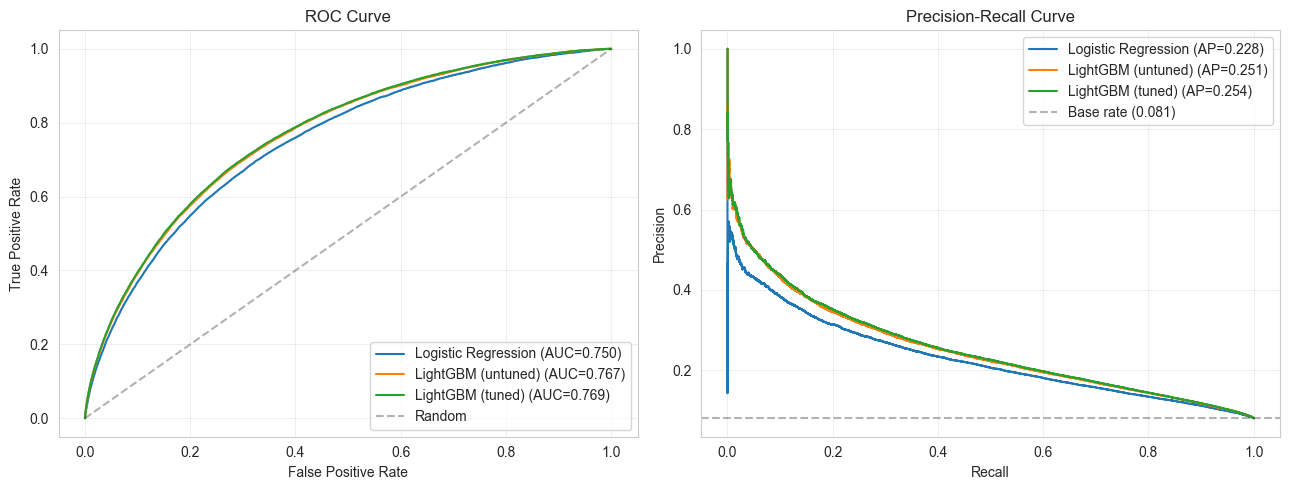

In [4]:
fig = plot_roc_pr_curves(y, y_scores, figsize=(13, 5))
fig.savefig(FIGURES_DIR / "roc_pr_curves.png")
plt.show()

**What to read in these plots:**

- **ROC (left):** the curves are close together near the diagonal lower-left corner — at low false positive rates, models behave similarly. They separate more visibly in the upper-middle of the curve, where the precision-recall trade-off lives.
- **PR (right):** the curve sits well above the base rate (0.0807, marked by the dashed line). At ~10% recall, all three models achieve precision around 0.35-0.45 — roughly 4-5x the base rate.

The visual gap between LightGBM (tuned) and LR is what 0.019 ROC-AUC looks like — clear separation but not overwhelming. That's the cost of interpretability.

## 4. KS statistic and score distributions

KS is computed as `max(|F_neg(s) - F_pos(s)|)` over all score thresholds — the largest gap between the cumulative distributions of defaulters and non-defaulters. Visually, plotting the two CDFs makes the separation obvious.

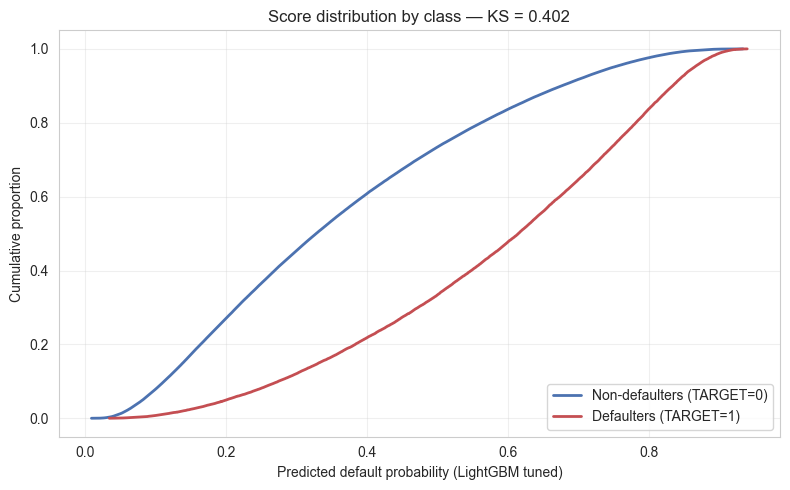

In [5]:
# Use the tuned LightGBM model for the KS visualisation
scores_tuned = oof["lgb_tuned_pred"].values

scores_pos = scores_tuned[y == 1]
scores_neg = scores_tuned[y == 0]

# Sort and compute CDFs
sorted_pos = np.sort(scores_pos)
sorted_neg = np.sort(scores_neg)
cdf_pos = np.arange(1, len(sorted_pos) + 1) / len(sorted_pos)
cdf_neg = np.arange(1, len(sorted_neg) + 1) / len(sorted_neg)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_neg, cdf_neg, label="Non-defaulters (TARGET=0)",
        color="#4c72b0", linewidth=2)
ax.plot(sorted_pos, cdf_pos, label="Defaulters (TARGET=1)",
        color="#c44e52", linewidth=2)
ax.set_xlabel("Predicted default probability (LightGBM tuned)")
ax.set_ylabel("Cumulative proportion")
ax.set_title(f"Score distribution by class — KS = {ks_statistic(y, scores_tuned):.3f}")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ks_distribution.png")
plt.show()

**What this plot shows:** if the model had no signal, the two CDFs would lie on top of each other. The gap between them at every point is the model's separating power at that threshold. The KS statistic is the height of the largest gap.

For LightGBM (tuned), we'd expect KS in the 0.36-0.40 range — solidly in the "acceptable" band, approaching "strong." This is consistent with what's reported in published Home Credit application-only solutions.

## 5. Calibration

A model is well-calibrated if its predicted probabilities correspond to observed frequencies: among applicants the model assigns 30% default risk to, roughly 30% actually default.

Calibration matters in credit beyond just ranking. If you're using the model's predicted probability for loss provisioning (expected loss = PD × LGD × EAD), the absolute level of the probability matters, not just the rank order. Miscalibrated predictions lead to misprovisioning.

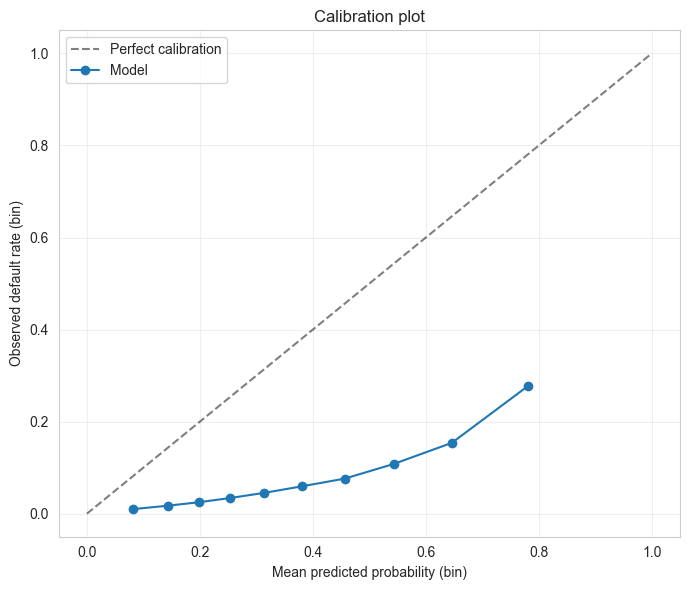

In [7]:
fig = plot_calibration(y, scores_tuned, n_bins=10, figsize=(7, 6))
fig.savefig(FIGURES_DIR / "calibration_tuned.png")
plt.show()

**Reading the calibration plot:**

- The dashed diagonal is perfect calibration
- Each blue dot is a decile of applicants binned by predicted probability — the x-axis is the bin's mean predicted probability, y-axis is the bin's observed default rate
- Dots above the diagonal: the model is **under-predicting** risk for that bin (saying 30%, observed 40%)
- Dots below the diagonal: the model is **over-predicting** risk

**Expected pattern for LightGBM with `scale_pos_weight`:** the model will systematically over-predict probabilities in absolute terms, because `scale_pos_weight` upweights the positive class to balance the loss. The ranking is still good (high ROC-AUC, high KS) but the predicted probabilities are inflated.

**What to do about this:** for v1 we leave it. Two reasons:

1. The model's ranking is what matters for the threshold-based use case (flag the top X% for review)
2. If absolute probabilities mattered for production deployment, we'd apply isotonic or sigmoid calibration on a held-out set — that's a v2 task

This is named in the README's "Limitations" section.

## 6. Threshold analysis

ROC-AUC and PR-AUC summarise performance across all thresholds. For deployment we have to pick one. Here we sweep thresholds and look at the operating-point metrics a credit team cares about:

- **flagged_pct** — fraction of applicants flagged at this threshold
- **captured_defaulters_pct** — fraction of actual defaulters caught (recall)
- **precision_at_threshold** — among those flagged, fraction that actually defaulted
- raw TP, FP, FN, TN counts

We use the tuned LightGBM scores throughout this section.

In [8]:
sweep = threshold_analysis(y, scores_tuned, thresholds=np.arange(0.10, 0.95, 0.05))
sweep["flagged_pct"] = (sweep["flagged_pct"] * 100).round(2)
sweep["captured_defaulters_pct"] = (sweep["captured_defaulters_pct"] * 100).round(2)
sweep["precision_at_threshold"] = (sweep["precision_at_threshold"] * 100).round(2)
sweep[["threshold", "flagged_pct", "captured_defaulters_pct",
       "precision_at_threshold", "tp", "fp", "fn", "tn"]]

,threshold,flagged_pct,captured_defaulters_pct,precision_at_threshold,tp,fp,fn,tn
0,0.10,92.64,99.24,8.65,24637,260233,188,22449
1,0.15,83.90,97.55,9.39,24217,233779,608,48903
2,0.20,74.68,95.04,10.27,23593,206044,1232,76638
3,0.25,65.68,91.83,11.29,22797,179181,2028,103501
4,0.30,57.21,87.88,12.40,21817,154109,3008,128573
5,0.35,49.42,83.35,13.61,20692,131291,4133,151391
6,0.40,42.24,78.11,14.93,19392,110510,5433,172172
7,0.45,35.75,72.57,16.39,18016,91921,6809,190761
8,0.50,29.73,66.49,18.06,16507,74905,8318,207777
9,0.55,24.25,59.62,19.85,14801,59755,10024,222927


**How to read this table:**

Each row says: "if we flag every applicant with predicted probability >= threshold, then X% of all applicants get flagged, we catch Y% of the actual defaulters, and Z% of the flagged applicants are real defaulters."

The trade-off is direct: lowering the threshold flags more applicants, catches more defaulters, but increases false positives.

## 7. Three candidate threshold choices

There's no universally correct threshold — it depends on the cost ratio between false positives (declining a good applicant, lost revenue) and false negatives (approving a bad applicant, lost principal). Three reasonable choices, explicitly named:

In [11]:
# Threshold 1: the conventional default
thr_default = 0.50

# Threshold 2: maximises F1
thresholds_search = np.arange(0.05, 0.95, 0.01)
f1_scores = []
for thr in thresholds_search:
    y_pred = (scores_tuned >= thr).astype(int)
    f1_scores.append(f1_score(y, y_pred))
thr_f1 = thresholds_search[np.argmax(f1_scores)]

# Threshold 3: flag top 10% riskiest (the operational view)
thr_top10 = np.quantile(scores_tuned, 0.90)

print(f"Threshold 1 (default 0.5):           {thr_default:.4f}")
print(f"Threshold 2 (F1-optimal):            {thr_f1:.4f}")
print(f"Threshold 3 (top-decile, 90th pctl): {thr_top10:.4f}")

Threshold 1 (default 0.5):           0.5000
Threshold 2 (F1-optimal):            0.6500
Threshold 3 (top-decile, 90th pctl): 0.7050


In [12]:
def threshold_metrics(y, scores, thr, name):
    y_pred = (scores >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    return {
        "choice": name,
        "threshold": round(thr, 4),
        "flagged_pct": round((tp + fp) / len(y) * 100, 2),
        "precision_pct": round(tp / (tp + fp) * 100, 2) if (tp + fp) else 0,
        "recall_pct": round(tp / (tp + fn) * 100, 2),
        "f1": round(f1_score(y, y_pred), 4),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }

comparison = pd.DataFrame([
    threshold_metrics(y, scores_tuned, thr_default, "Default 0.5"),
    threshold_metrics(y, scores_tuned, thr_f1, "F1-optimal"),
    threshold_metrics(y, scores_tuned, thr_top10, "Top-decile"),
])
comparison

,choice,threshold,flagged_pct,precision_pct,recall_pct,f1,tp,fp,fn,tn
0,Default 0.5,0.500,29.73,18.06,66.49,0.2840,16507,74905,8318,207777
1,F1-optimal,0.650,14.57,24.33,43.93,0.3132,10905,33914,13920,248768
2,Top-decile,0.705,10.00,27.77,34.40,0.3073,8539,22212,16286,260470


**How to read the three choices:**

- **Default 0.5** is shown for completeness — it's a sanity check that we're not using it. With `scale_pos_weight` inflating predicted probabilities, ~50% of applicants would be flagged at 0.5 (which is too many). This is exactly the trap we avoid by choosing a threshold deliberately.

- **F1-optimal** balances precision and recall mathematically. F1 is the harmonic mean — it penalises imbalance between the two. Useful for fair comparisons but doesn't directly map to business cost.

- **Top-decile** is the threshold that flags the riskiest 10% of applicants for review. This is closest to how a credit team would actually deploy: "send the top 10% to manual review or decline outright, auto-approve the rest." The flagged_pct should be exactly 10% by construction. The recall at this threshold tells you what fraction of actual defaulters land in the top decile.

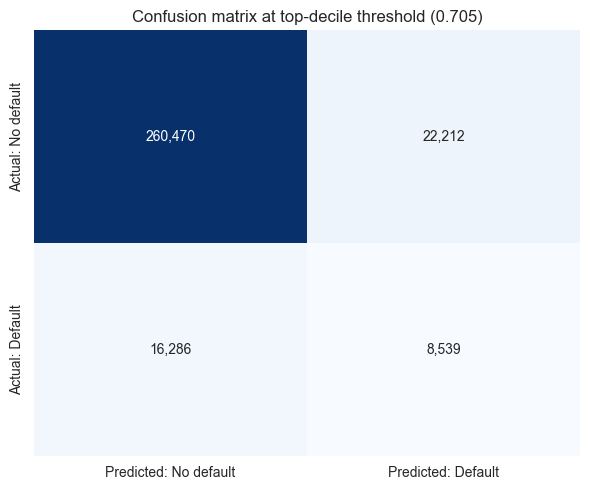

In [13]:
# Visualise the confusion matrix at the top-decile threshold
y_pred_top10 = (scores_tuned >= thr_top10).astype(int)
cm = confusion_matrix(y, y_pred_top10)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False,
            xticklabels=["Predicted: No default", "Predicted: Default"],
            yticklabels=["Actual: No default", "Actual: Default"], ax=ax)
ax.set_title(f"Confusion matrix at top-decile threshold ({thr_top10:.3f})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix_top_decile.png")
plt.show()

## 8. Business framing — what this model would do, honestly

Now we translate the threshold analysis into language a credit team would use. The framing is deliberately scoped to the observed historical population, not a counterfactual.

**At the top-decile threshold:**

The model identifies the riskiest 10% of historical applicants. Among that 10%:
- A meaningful share (precision_pct) are actual defaulters
- This share is much higher than the population base rate of 8.07% — that's the model's lift over random
- The captured recall tells us what proportion of the total defaulters we catch by flagging this top decile

**What this means operationally:**

A lender could deploy this model as a triage step: applications with predicted probability above the top-decile threshold get sent to manual review or are declined outright; the rest get auto-approved or fast-tracked. This is not the same as saying "we'd approve X% more applicants" — that claim requires modelling outcomes for declined applicants (reject inference), which we have not done.

**What this does NOT mean:**

- It does NOT mean we'd catch 100% of defaulters (the bottom 90% of risk still contains real defaulters)
- It does NOT mean the predicted probability of e.g. 25% means "25% of these will default" — see the calibration discussion above
- It does NOT mean the model would generalise to a different applicant population, a different macroeconomic regime, or a different lending product


In [15]:
# Compute the actual numbers for the README's business framing language
chosen = threshold_metrics(y, scores_tuned, thr_top10, "Top-decile")
print(f"At the top-decile threshold ({thr_top10:.3f}):")
print(f"  - {chosen['flagged_pct']}% of applicants would be flagged")
print(f"  - {chosen['precision_pct']}% of flagged applicants are actual defaulters")
print(f"    (vs population base rate of 8.07% — {chosen['precision_pct']/8.07:.1f}x lift)")
print(f"  - {chosen['recall_pct']}% of all defaulters are captured in the flagged set")

At the top-decile threshold (0.705):
  - 10.0% of applicants would be flagged
  - 27.77% of flagged applicants are actual defaulters
    (vs population base rate of 8.07% — 3.4x lift)
  - 34.4% of all defaulters are captured in the flagged set


## 9. Summary

### What this notebook produced
- Headline metrics table comparing all three models (ROC-AUC, PR-AUC, KS, base rate)
- `reports/figures/roc_pr_curves.png` — README-embeddable
- `reports/figures/ks_distribution.png` — CDF separation between classes
- `reports/figures/calibration_tuned.png` — calibration assessment for tuned LightGBM
- `reports/figures/confusion_matrix_top_decile.png` — operating-point view
- Three threshold choices with explicit trade-offs (default, F1-optimal, top-decile)
- Business framing language for the README, scoped honestly to historical observed distribution

### Important caveats (named in README "Limitations")
- Predicted probabilities are not calibrated — the model is for ranking, not loss provisioning
- No reject inference — claims about approving more applicants are out of scope
- No bureau / previous_application features — published solutions get further lift here
- No time-based validation split — folds are random, not chronological
- No fairness / disparate impact analysis

### What `05_interpretation.ipynb` does next
- Load the final tuned LightGBM model from `models/lightgbm_final.txt`
- SHAP TreeExplainer global summary plot
- 3 individual prediction explanations (high-risk default case, low-risk repay case, borderline case)
- Brief narrative on which features the model is doing the work with